# Linear drag (Taylor 2.1-2.2)

**Class notebook, PHY 317 (Smith, Fall 2026).** A Python version of Will Raven's *Linear Drag* Mathematica notebook. Runs as-is on posit.smith.edu.

Drag on a sphere of diameter $D$ moving at speed $v$ through a fluid is
$$f(v) = b v + c v^2, \qquad b = \beta D, \quad c = \gamma D^2,$$
with $\beta = 1.6\times10^{-4}\ \mathrm{N\,s/m^2}$ and $\gamma = 0.25\ \mathrm{N\,s^2/m^4}$ for air at STP (Taylor Eqs. 2.4-2.6). The first thing to do with any projectile is decide which term matters:
$$\frac{f_{\rm quad}}{f_{\rm lin}} = \frac{\gamma}{\beta} D v \approx (1.6\times10^3\ \mathrm{s/m^2})\, D v .$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

beta, gamma = 1.6e-4, 0.25      # air at STP, SI
g = 9.8

def ratio(D, v):
    """f_quad / f_lin for a sphere of diameter D at speed v (SI)."""
    return gamma / beta * D * v

for name, D, v in [("baseball", 0.07, 5), ("raindrop", 1e-3, 0.6), ("oil drop", 1.5e-6, 5e-5)]:
    print(f"{name:9s}: f_quad/f_lin = {ratio(D, v):.1e}")

baseball : f_quad/f_lin = 5.5e+02
raindrop : f_quad/f_lin = 9.4e-01
oil drop : f_quad/f_lin = 1.2e-07


So a baseball is quadratic-drag territory, a raindrop needs both terms, and a Millikan oil drop is purely linear. The rest of this notebook is the **linear** case, which is the one we can solve in closed form, because the $x$ and $y$ equations decouple:
$$m\dot v_x = -b v_x, \qquad m\dot v_y = -mg - b v_y \quad(y\ \text{up}).$$
Solutions (Taylor 2.2, with $\tau = m/b$ and $v_{\rm ter} = mg/b$):
$$v_x = v_{x0}\,e^{-t/\tau}, \qquad x = v_{x0}\tau\,(1 - e^{-t/\tau}),$$
$$v_y = -v_{\rm ter} + (v_{y0} + v_{\rm ter})\,e^{-t/\tau}, \qquad y = -v_{\rm ter}\,t + (v_{y0} + v_{\rm ter})\,\tau\,(1 - e^{-t/\tau}).$$
(Watch the sign convention: Taylor uses $y$ **down** in 2.2 and switches to $y$ **up** for the range problem in 2.3. Everything here is $y$ up.)

In [2]:
def linear_drag(t, m, b, vx0, vy0):
    tau = m / b
    vter = m * g / b
    vx = vx0 * np.exp(-t / tau)
    x = vx0 * tau * (1 - np.exp(-t / tau))
    vy = -vter + (vy0 + vter) * np.exp(-t / tau)
    y = -vter * t + (vy0 + vter) * tau * (1 - np.exp(-t / tau))
    return x, y, vx, vy

def sphere_b(D, eta=1.7e-5):
    """Stokes's law b = 3 pi eta D. eta = viscosity (air 1.7e-5, water 1.0e-3 Pa s)."""
    return 3 * np.pi * eta * D

## The horizontal and vertical pieces, for several time constants

Change `taus` (in seconds) and the initial velocities. Landmarks to look for: $v_x$ falls to $e^{-1} \approx 37\%$ of its start after one $\tau$; $x$ never passes $v_{x0}\tau$; $v_y$ is within 5% of $-v_{\rm ter}$ after $3\tau$.

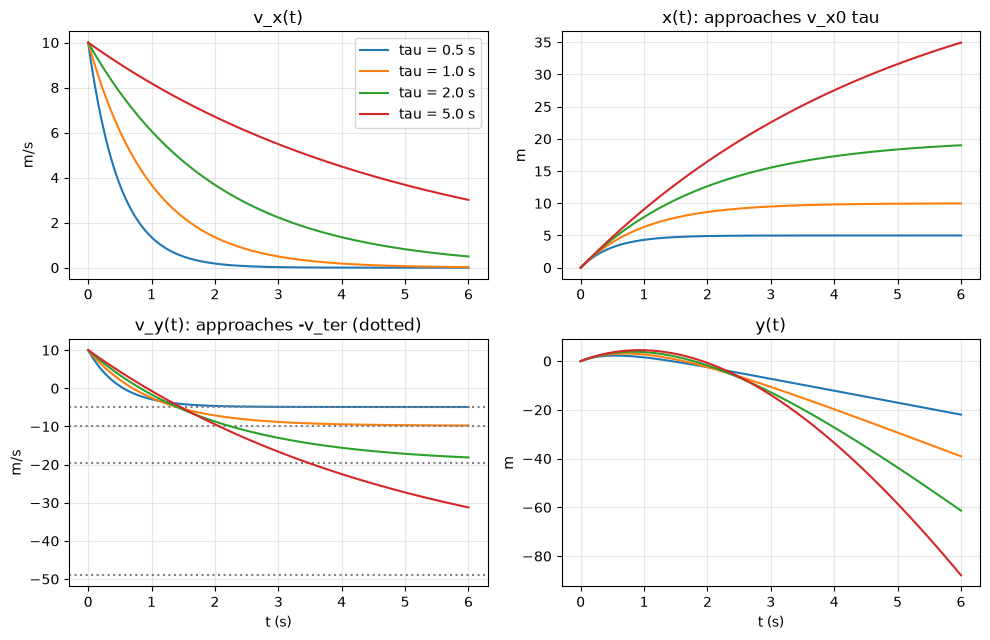

In [3]:
m = 1.0                    # kg (only the ratio m/b matters for the shapes)
vx0, vy0 = 10.0, 10.0      # m/s
taus = [0.5, 1.0, 2.0, 5.0]   # s

t = np.linspace(0, 6, 600)
fig, ax = plt.subplots(2, 2, figsize=(10, 6.5))
for tau in taus:
    b = m / tau
    x, y, vx, vy = linear_drag(t, m, b, vx0, vy0)
    ax[0, 0].plot(t, vx, label=f"tau = {tau} s")
    ax[0, 1].plot(t, x)
    ax[1, 0].plot(t, vy)
    ax[1, 1].plot(t, y)
    ax[1, 0].axhline(-m * g / b, ls=":", color="gray")   # -v_ter for this tau
ax[0, 0].set(title="v_x(t)", ylabel="m/s"); ax[0, 0].legend()
ax[0, 1].set(title="x(t): approaches v_x0 tau", ylabel="m")
ax[1, 0].set(title="v_y(t): approaches -v_ter (dotted)", xlabel="t (s)", ylabel="m/s")
ax[1, 1].set(title="y(t)", xlabel="t (s)", ylabel="m")
for a in ax.flat: a.grid(alpha=0.3)
plt.tight_layout()

## Real objects: what is $\tau$ actually?

Stokes's law gives $b = 3\pi\eta D$, so $\tau = m/b$. Try Taylor's examples: a Millikan oil drop ($D = 1.5\,\mu$m, density 840 kg/m$^3$) and a 0.2 mm water drop.

In [4]:
for name, D, rho_obj, eta in [("oil drop", 1.5e-6, 840.0, 1.7e-5),
                                ("water drop", 2e-4, 1000.0, 1.7e-5)]:
    m_obj = rho_obj * np.pi * D**3 / 6
    b = sphere_b(D, eta)
    tau = m_obj / b
    print(f"{name:10s}: m = {m_obj:.2e} kg, b = {b:.2e} kg/s, tau = {tau:.2e} s, v_ter = {m_obj*g/b:.2e} m/s")

oil drop  : m = 1.48e-15 kg, b = 2.40e-10 kg/s, tau = 6.18e-06 s, v_ter = 6.05e-05 m/s
water drop: m = 4.19e-09 kg, b = 3.20e-08 kg/s, tau = 1.31e-01 s, v_ter = 1.28e+00 m/s


## Check against a numerical solution

Nothing above needed a computer. This cell integrates the equations of motion numerically and overlays the analytic solution, which is how you should check *your* formulas in the homework.

In [5]:
from scipy.integrate import solve_ivp

def rhs(t, s, m, b):
    x, y, vx, vy = s
    return [vx, vy, -b/m * vx, -g - b/m * vy]

m, tau = 1.0, 1.5
b = m / tau
sol = solve_ivp(rhs, (0, 6), [0, 0, vx0, vy0], args=(m, b), t_eval=t, rtol=1e-9)
x, y, vx, vy = linear_drag(t, m, b, vx0, vy0)
print("max |y_numeric - y_analytic| =", np.max(np.abs(sol.y[1] - y)), "m")

max |y_numeric - y_analytic| = 3.364032017394436e-07 m
